
# XGBoost Restaurant Ranking

Notebook nay duoc chinh lai de khop voi 2 file CSV hien tai trong `dataset/`.
Toan bo logic duoc nhung truc tiep trong notebook, khong con phu thuoc vao file helper ben ngoai khi chay.


## Base Helpers

In [20]:
from __future__ import annotations

import re
import time
import unicodedata
from collections import defaultdict
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ndcg_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from xgboost import XGBRanker

RANDOM_STATE = 42

STOPWORDS = {
    "toi",
    "muon",
    "hay",
    "cho",
    "biet",
    "tim",
    "kiem",
    "giup",
    "mot",
    "1",
    "nhung",
    "cac",
    "quan",
    "nha",
    "hang",
    "an",
    "o",
    "va",
    "co",
    "nao",
    "de",
    "di",
    "vao",
    "ban",
    "duoc",
    "goi",
    "y",
    "liet",
    "ke",
    "cua",
    "phu",
    "hop",
    "moi",
}

GENERIC_QUERY_TOKENS = STOPWORDS | {"mon", "do", "am", "thuc", "uong", "ngon"}

TIME_SLOTS = {
    "sang": 8 * 60,
    "trua": 12 * 60,
    "chieu": 15 * 60,
    "toi": 19 * 60,
}

DAY_MAP = {
    "chu nhat": "chu_nhat",
    "thu hai": "thu_hai",
    "thu ba": "thu_ba",
    "thu tu": "thu_tu",
    "thu nam": "thu_nam",
    "thu sau": "thu_sau",
    "thu bay": "thu_bay",
}

AUDIENCE_PATTERNS = {
    "sinh vien": ["sinh vien"],
    "cap doi": ["cap doi"],
    "gia dinh": ["gia dinh"],
    "nhom hoi": ["nhom hoi"],
    "dan van phong": ["dan van phong", "van phong"],
    "khach du lich": ["khach du lich"],
}

FEATURE_COLUMNS = [
    "tfidf_cosine",
    "text_overlap_ratio",
    "name_overlap_ratio",
    "cuisine_overlap_ratio",
    "category_overlap_ratio",
    "district_exact_match",
    "district_partial_match",
    "audience_match_ratio",
    "budget_fit",
    "budget_gap_ratio",
    "delivery_match",
    "booking_match",
    "open_day_match",
    "day_requested",
    "affordable_intent",
    "luxury_intent",
    "quality_intent",
    "service_intent",
    "space_intent",
    "position_intent",
    "popularity_intent",
    "delivery_required",
    "booking_required",
    "cheapness_score",
    "luxury_score",
    "price_mid",
    "vi_tri",
    "gia_ca",
    "chat_luong",
    "phuc_vu",
    "khong_gian",
    "quality_score_mean",
    "log_totalview",
    "log_totalfavourite",
    "log_totalcheckins",
    "positive_review_ratio",
    "negative_review_ratio",
]


def normalize_text(text: Any) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower().replace("đ", "d")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def slugify_column_name(name: Any) -> str:
    text = str(name).replace("Đ", "D").replace("đ", "d")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-zA-Z0-9]+", "_", text)
    return text.strip("_").lower()


def tokenize(text: Any) -> list[str]:
    return [tok for tok in normalize_text(text).split() if tok and tok not in STOPWORDS]


def contains_phrase(text: Any, phrase: Any) -> bool:
    text_norm = normalize_text(text)
    phrase_norm = normalize_text(phrase)
    if not text_norm or not phrase_norm:
        return False
    pattern = rf"(?<![a-z0-9]){re.escape(phrase_norm)}(?![a-z0-9])"
    return re.search(pattern, text_norm) is not None


def normalize_restaurant_id(value: Any) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    try:
        return str(int(float(text)))
    except Exception:
        return text


def parse_number_with_unit(fragment: str) -> float:
    fragment = normalize_text(fragment)
    match = re.search(r"(\d+(?:[\.,]\d+)?)", fragment)
    if not match:
        return np.nan
    number = float(match.group(1).replace(",", "."))
    if "trieu" in fragment:
        return number * 1_000_000
    if any(unit in fragment for unit in ("nghin", "ngan", "k")):
        return number * 1_000
    if number <= 500:
        return number * 1_000
    return number


def extract_budget_ceiling(query: str) -> float:
    query_norm = normalize_text(query)
    patterns = [
        r"gia\s*toi\s*da\s*la\s*([^,.;]+)",
        r"toi\s*da\s*([^,.;]+)",
        r"duoi\s*([^,.;]+)",
        r"khong\s*qua\s*([^,.;]+)",
    ]
    for pattern in patterns:
        match = re.search(pattern, query_norm)
        if match:
            value = parse_number_with_unit(match.group(1))
            if not pd.isna(value):
                return float(value)
    return np.nan


def extract_day_targets(query: str) -> list[str]:
    query_norm = normalize_text(query)
    days = [slug for phrase, slug in DAY_MAP.items() if contains_phrase(query_norm, phrase)]
    if "cuoi tuan" in query_norm:
        days.extend(["thu_bay", "chu_nhat"])
    return sorted(set(days))


def extract_time_slot(query: str) -> str:
    query_norm = normalize_text(query)
    if "buoi sang" in query_norm or contains_phrase(query_norm, "sang"):
        return "sang"
    if "buoi trua" in query_norm or contains_phrase(query_norm, "trua"):
        return "trua"
    if "buoi chieu" in query_norm or contains_phrase(query_norm, "chieu"):
        return "chieu"
    if "buoi toi" in query_norm or contains_phrase(query_norm, "toi"):
        return "toi"
    return ""


def minute_of_day(value: str) -> int:
    hour, minute = value.split(":")
    return int(hour) * 60 + int(minute)


def parse_day_schedule(value: Any) -> tuple[float, float]:
    text = str(value).strip()
    match = re.search(r"\(\('([0-9]{2}:[0-9]{2})',\s*'([0-9]{2}:[0-9]{2})'\),\s*(True|False)\)", text)
    if not match:
        return (np.nan, np.nan)
    open_time, close_time, _ = match.groups()
    return (minute_of_day(open_time), minute_of_day(close_time))


def is_open_for_slot(value: Any, slot: str) -> float:
    open_min, close_min = parse_day_schedule(value)
    if pd.isna(open_min) or pd.isna(close_min):
        return 0.0
    target = TIME_SLOTS.get(slot)
    if target is None:
        return 1.0
    if close_min <= open_min:
        close_min += 24 * 60
        if target < open_min:
            target += 24 * 60
    return float(open_min <= target <= close_min)


def extract_audience_targets(query: str) -> list[str]:
    query_norm = normalize_text(query)
    targets: list[str] = []
    for label, patterns in AUDIENCE_PATTERNS.items():
        if any(contains_phrase(query_norm, pattern) for pattern in patterns):
            targets.append(label)
    return targets


def match_overlap_ratio(query_tokens: list[str], text: str) -> float:
    text_tokens = set(tokenize(text))
    content_tokens = {tok for tok in query_tokens if tok not in GENERIC_QUERY_TOKENS}
    if not content_tokens:
        return 0.0
    return len(content_tokens & text_tokens) / len(content_tokens)


def audience_match_ratio(targets: list[str], audience_text: str) -> float:
    audience_norm = normalize_text(audience_text)
    if not targets:
        return 0.0
    matched = sum(1 for target in targets if contains_phrase(audience_norm, target))
    return matched / len(targets)


def extract_query_flags(query: str) -> dict[str, float]:
    query_norm = normalize_text(query)
    return {
        "affordable_intent": float(
            any(
                pattern in query_norm
                for pattern in ("gia ca phai chang", "gia tot", "gia re", "binh dan", "hop tui tien")
            )
        ),
        "luxury_intent": float(any(pattern in query_norm for pattern in ("sang trong", "cao cap"))),
        "quality_intent": float(
            any(pattern in query_norm for pattern in ("danh gia cao", "chat luong", "ngon", "review tot"))
        ),
        "service_intent": float("phuc vu" in query_norm),
        "space_intent": float(any(pattern in query_norm for pattern in ("khong gian", "yen tinh", "thoai mai", "dep"))),
        "position_intent": float("vi tri" in query_norm),
        "popularity_intent": float(
            any(pattern in query_norm for pattern in ("luot xem nhieu", "duoc yeu thich", "dong khach", "noi tieng"))
        ),
        "delivery_required": float(any(pattern in query_norm for pattern in ("giao hang", "giao tan noi", "ship"))),
        "booking_required": float("dat ban" in query_norm),
    }


def compute_group_metrics(eval_df: pd.DataFrame, score_col: str = "pred_score", top_ks: tuple[int, ...] = (5, 10)) -> dict[str, float]:
    ndcg_store = defaultdict(list)
    mrr_store: list[float] = []
    hit_store = {k: [] for k in top_ks}

    for _, group in eval_df.groupby("query"):
        group = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        y_true = group["label"].to_numpy(dtype=float)
        y_score = group[score_col].to_numpy(dtype=float)

        for k in top_ks:
            score = ndcg_score([y_true], [y_score], k=min(k, len(group)))
            ndcg_store[k].append(float(score))

        relevant_positions = np.where(group["label"].to_numpy() >= 4)[0]
        mrr_store.append(float(1.0 / (relevant_positions[0] + 1)) if len(relevant_positions) else 0.0)

        for k in top_ks:
            hit_store[k].append(float((group["label"].head(k) >= 4).any()))

    metrics = {f"NDCG@{k}": float(np.mean(values)) for k, values in ndcg_store.items()}
    metrics["MRR"] = float(np.mean(mrr_store))
    for k in top_ks:
        metrics[f"HIT@{k}"] = float(np.mean(hit_store[k]))
    return metrics


def default_ranker(random_state: int = RANDOM_STATE, n_estimators: int = 250) -> XGBRanker:
    return XGBRanker(
        objective="rank:pairwise",
        eval_metric=["ndcg@5", "ndcg@10"],
        learning_rate=0.05,
        n_estimators=n_estimators,
        max_depth=6,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=random_state,
    )


def load_merged_restaurant_ranking(
    labels_path: str | Path = Path("..") / "dataset" / "restaurant_dataset_ver1.csv",
    restaurants_path: str | Path = Path("..") / "dataset" / "foody_combined_data_final.csv",
) -> pd.DataFrame:
    labels_df = pd.read_csv(labels_path).rename(
        columns={
            "district": "label_district",
            "cuisines": "label_cuisines",
            "source": "retrieval_source",
        }
    )
    restaurants_df = pd.read_csv(restaurants_path)
    restaurants_df = restaurants_df.rename(columns={col: slugify_column_name(col) for col in restaurants_df.columns})
    restaurants_df = restaurants_df.rename(
        columns={
            "restaurantid": "restaurant_id",
            "name": "restaurant_name_meta",
            "district": "district_meta",
            "area": "area_meta",
            "address": "address_meta",
            "metakeywords": "meta_keywords",
            "cuisines": "cuisines_meta",
            "lsttargetaudience": "target_audience_meta",
            "lstcategory": "category_meta",
        }
    )

    labels_df["restaurant_id"] = labels_df["restaurant_id"].map(normalize_restaurant_id)
    restaurants_df["restaurant_id"] = restaurants_df["restaurant_id"].map(normalize_restaurant_id)

    df = labels_df.merge(restaurants_df, on="restaurant_id", how="left", validate="many_to_one")
    return df


def build_restaurant_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    numeric_columns = [
        "pricemin",
        "pricemax",
        "vi_tri",
        "gia_ca",
        "chat_luong",
        "phuc_vu",
        "khong_gian",
        "excellent",
        "good",
        "average",
        "bad",
        "totalview",
        "totalfavourite",
        "totalcheckins",
    ]
    for col in numeric_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    for col in ("delivery_flag", "booking_flag", "giao_tan_noi", "dat_ban"):
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    text_columns = [
        "restaurant_name_meta",
        "address_meta",
        "district_meta",
        "area_meta",
        "meta_keywords",
        "cuisines_meta",
        "target_audience_meta",
        "category_meta",
    ]
    for col in text_columns:
        df[col] = df[col].fillna("").astype(str)

    df["restaurant_text"] = df[text_columns].agg(" | ".join, axis=1)
    df["query_norm"] = df["query"].map(normalize_text)
    df["restaurant_text_norm"] = df["restaurant_text"].map(normalize_text)
    df["district_norm"] = df["district_meta"].map(normalize_text)
    df["audience_norm"] = df["target_audience_meta"].map(normalize_text)
    df["query_tokens"] = df["query"].map(tokenize)

    df["price_mid"] = ((df["pricemin"] + df["pricemax"]) / 2.0).fillna(0.0)
    df["log_totalview"] = np.log1p(df["totalview"])
    df["log_totalfavourite"] = np.log1p(df["totalfavourite"])
    df["log_totalcheckins"] = np.log1p(df["totalcheckins"])
    df["review_count"] = df[["excellent", "good", "average", "bad"]].sum(axis=1)
    df["positive_review_ratio"] = np.where(
        df["review_count"] > 0,
        (df["excellent"] + df["good"]) / df["review_count"],
        0.0,
    )
    df["negative_review_ratio"] = np.where(
        df["review_count"] > 0,
        df["bad"] / df["review_count"],
        0.0,
    )
    df["quality_score_mean"] = df[["vi_tri", "gia_ca", "chat_luong", "phuc_vu", "khong_gian"]].mean(axis=1)
    df["delivery_available"] = ((df["delivery_flag"] > 0) | (df["giao_tan_noi"] > 0)).astype(float)
    df["booking_available"] = ((df["booking_flag"] > 0) | (df["dat_ban"] > 0)).astype(float)

    district_candidates = sorted(
        {
            normalize_text(x)
            for x in pd.concat([df["district_meta"], df["label_district"]]).dropna().astype(str)
            if normalize_text(x)
        },
        key=len,
        reverse=True,
    )

    def extract_district_target(query: str) -> str:
        query_norm = normalize_text(query)
        for district in district_candidates:
            if contains_phrase(query_norm, district):
                return district
        if "thu duc" in query_norm:
            return "thu duc"
        return ""

    query_rows: list[dict[str, Any]] = []
    for query in df["query"].drop_duplicates():
        row = {
            "query": query,
            "district_target": extract_district_target(query),
            "day_targets": extract_day_targets(query),
            "time_slot": extract_time_slot(query),
            "budget_ceiling": extract_budget_ceiling(query),
            "audience_targets": extract_audience_targets(query),
        }
        row.update(extract_query_flags(query))
        query_rows.append(row)

    query_profile_df = pd.DataFrame(query_rows)
    df = df.merge(query_profile_df, on="query", how="left", validate="many_to_one")

    df["text_overlap_ratio"] = [
        match_overlap_ratio(query_tokens, text)
        for query_tokens, text in zip(df["query_tokens"], df["restaurant_text"])
    ]
    df["name_overlap_ratio"] = [
        match_overlap_ratio(query_tokens, text)
        for query_tokens, text in zip(df["query_tokens"], df["restaurant_name_meta"])
    ]
    df["cuisine_overlap_ratio"] = [
        match_overlap_ratio(query_tokens, text)
        for query_tokens, text in zip(df["query_tokens"], df["cuisines_meta"] + " " + df["meta_keywords"])
    ]
    df["category_overlap_ratio"] = [
        match_overlap_ratio(query_tokens, text)
        for query_tokens, text in zip(df["query_tokens"], df["category_meta"])
    ]

    df["district_exact_match"] = (
        (df["district_target"] != "") & (df["district_norm"] == df["district_target"])
    ).astype(float)
    df["district_partial_match"] = [
        0.0
        if not district_target
        else float(
            district_target == district_norm
            or district_target in district_norm
            or district_norm in district_target
        )
        for district_target, district_norm in zip(df["district_target"], df["district_norm"])
    ]

    df["audience_match_ratio"] = [
        audience_match_ratio(targets, audience_text)
        for targets, audience_text in zip(df["audience_targets"], df["audience_norm"])
    ]
    df["budget_fit"] = [
        float((not pd.isna(budget)) and budget > 0 and price_mid <= budget)
        for budget, price_mid in zip(df["budget_ceiling"], df["price_mid"])
    ]
    df["budget_gap_ratio"] = [
        0.0 if pd.isna(budget) or budget <= 0 else max(price_mid - budget, 0.0) / budget
        for budget, price_mid in zip(df["budget_ceiling"], df["price_mid"])
    ]
    df["cheapness_score"] = 1.0 / (1.0 + np.log1p(df["price_mid"].clip(lower=0.0)))
    df["luxury_score"] = np.log1p(df["price_mid"].clip(lower=0.0))
    df["delivery_match"] = np.where(df["delivery_required"] > 0, df["delivery_available"], 0.0)
    df["booking_match"] = np.where(df["booking_required"] > 0, df["booking_available"], 0.0)

    for col in DAY_MAP.values():
        if col not in df.columns:
            df[col] = ""

    def open_day_match(row: pd.Series) -> float:
        if not row["day_targets"]:
            return 0.0
        scores = [is_open_for_slot(row[day], row["time_slot"]) for day in row["day_targets"]]
        return max(scores) if scores else 0.0

    df["open_day_match"] = df.apply(open_day_match, axis=1)
    df["day_requested"] = df["day_targets"].map(lambda value: float(len(value) > 0))

    restaurants = df[["restaurant_id", "restaurant_text_norm"]].drop_duplicates("restaurant_id").reset_index(drop=True)
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    restaurant_matrix = vectorizer.fit_transform(restaurants["restaurant_text_norm"])
    restaurant_index = {restaurant_id: idx for idx, restaurant_id in enumerate(restaurants["restaurant_id"])}
    query_matrix = vectorizer.transform(df["query_norm"])
    df["tfidf_cosine"] = [
        float(cosine_similarity(query_matrix[i], restaurant_matrix[restaurant_index[restaurant_id]])[0, 0])
        for i, restaurant_id in enumerate(df["restaurant_id"])
    ]

    for col in FEATURE_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    return df


def query_profile_columns() -> list[str]:
    return [
        "query",
        "district_target",
        "day_targets",
        "time_slot",
        "budget_ceiling",
        "audience_targets",
        "delivery_required",
        "booking_required",
        "affordable_intent",
        "luxury_intent",
        "quality_intent",
        "service_intent",
        "space_intent",
        "position_intent",
        "popularity_intent",
    ]


def split_by_query(df: pd.DataFrame, random_state: int = RANDOM_STATE) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    unique_queries = df["query"].drop_duplicates().to_numpy()
    train_queries, temp_queries = train_test_split(unique_queries, test_size=0.30, random_state=random_state)
    val_queries, test_queries = train_test_split(temp_queries, test_size=0.50, random_state=random_state)

    def subset(query_values: np.ndarray) -> pd.DataFrame:
        return (
            df[df["query"].isin(query_values)]
            .sort_values(["query", "restaurant_id"])
            .reset_index(drop=True)
        )

    return subset(train_queries), subset(val_queries), subset(test_queries)


def group_sizes(df: pd.DataFrame) -> list[int]:
    return df.groupby("query").size().tolist()


def train_ranker(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    feature_columns: list[str] | None = None,
    random_state: int = RANDOM_STATE,
    n_estimators: int = 250,
) -> tuple[XGBRanker, float]:
    feature_columns = feature_columns or FEATURE_COLUMNS
    ranker = default_ranker(random_state=random_state, n_estimators=n_estimators)

    start_time = time.time()
    ranker.fit(
        train_df[feature_columns],
        train_df["label"],
        group=group_sizes(train_df),
        eval_set=[(val_df[feature_columns], val_df["label"])],
        eval_group=[group_sizes(val_df)],
        verbose=False,
    )
    elapsed = time.time() - start_time
    return ranker, elapsed


def evaluate_ranker(
    ranker: XGBRanker,
    test_df: pd.DataFrame,
    feature_columns: list[str] | None = None,
) -> tuple[pd.DataFrame, dict[str, float]]:
    feature_columns = feature_columns or FEATURE_COLUMNS
    eval_df = test_df.copy()
    eval_df["pred_score"] = ranker.predict(eval_df[feature_columns])
    metrics = compute_group_metrics(eval_df, score_col="pred_score")
    return eval_df, metrics


def feature_importance_frame(
    ranker: XGBRanker,
    feature_columns: list[str] | None = None,
) -> pd.DataFrame:
    feature_columns = feature_columns or FEATURE_COLUMNS
    return (
        pd.DataFrame({"feature": feature_columns, "importance": ranker.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


## Query And Feature Overrides For Current CSV

In [21]:
DAY_COLUMNS = ["thu_hai", "thu_ba", "thu_tu", "thu_nam", "thu_sau", "thu_bay", "chu_nhat"]
TIME_SLOTS = {
    "breakfast": 7 * 60 + 30,
    "brunch": 10 * 60 + 30,
    "lunch": 12 * 60 + 30,
    "afternoon": 15 * 60 + 30,
    "dinner": 19 * 60 + 30,
    "late_night": 22 * 60 + 30,
}
GENERIC_QUERY_TOKENS = STOPWORDS | {
    "mon", "do", "am", "thuc", "gia", "ngon", "dep", "tot", "on", "chat", "luong", "phuc", "vu",
    "khong", "gian", "vi", "tri", "nhieu", "nguoi", "review", "danh", "cao", "re", "mem", "tuan",
    "ngay", "thu", "sang", "trua", "chieu", "toi", "giao", "hang", "tan", "noi", "ban", "bua",
    "mo", "cua", "rat", "qua", "chi", "can",
}
AUDIENCE_PATTERNS = {
    "sinh vien": ["sinh vien", "hoc sinh sinh vien"],
    "cap doi": ["cap doi", "hen ho", "lang man"],
    "gia dinh": ["gia dinh", "ba me"],
    "nhom hoi": ["nhom hoi", "nhom dong nguoi", "team cong ty", "hop nhom"],
    "nhom ban": ["nhom ban", "ban be", "tu tap ban be", "gap ban cu"],
    "dan van phong": ["dan van phong", "gioi van phong", "van phong", "com van phong"],
    "gioi manager": ["manager", "tiep khach", "khach hang", "doi tac", "doanh nghiep"],
    "khach du lich": ["khach du lich", "khach nuoc ngoai"],
    "tre em": ["tre em"],
    "nguoi lon tuoi": ["nguoi lon tuoi"],
}
CATEGORY_PATTERNS = {
    "an_vat": {"query": ["an vat", "do an vat"], "meta": ["an vat", "via he"]},
    "cafe_dessert": {"query": ["cafe", "ca phe", "dessert", "tra sua", "tra banh", "brunch", "tiem banh", "banh ngot"], "meta": ["cafe", "dessert", "tiem banh"]},
    "buffet": {"query": ["buffet"], "meta": ["buffet"]},
    "bar_pub": {"query": ["bar", "pub", "lounge"], "meta": ["bar pub", "beer club", "lounge"]},
    "quan_nhau": {"query": ["nhau", "beer garden", "beer club"], "meta": ["quan nhau", "beer club", "beer garden"]},
    "an_chay": {"query": ["chay"], "meta": ["an chay"]},
    "lau": {"query": ["lau", "lau bo", "lau ca", "lau nam"], "meta": ["lau"]},
    "nuong_bbq": {"query": ["nuong", "bbq"], "meta": ["nuong", "bbq"]},
}
CUISINE_PATTERNS = {
    "mon_viet": {"query": ["mon viet", "viet nam"], "meta": ["mon viet"]},
    "mon_han": {"query": ["han quoc", "mon han", "bbq han quoc"], "meta": ["mon han", "han quoc"]},
    "mon_nhat": {"query": ["mon nhat", "sushi", "ramen"], "meta": ["mon nhat", "nhat"]},
    "mon_thai": {"query": ["thai lan", "mon thai"], "meta": ["mon thai", "thai"]},
    "mon_au": {"query": ["mon au", "chau au", "steak"], "meta": ["mon au", "quoc te", "phap", "my"]},
    "mon_y": {"query": ["mon y", "mi y", "pizza", "italy", "italian"], "meta": ["mon y", "italy", "pizza"]},
    "mon_trung_hoa": {"query": ["trung hoa", "mon hoa", "dimsum", "dim sum"], "meta": ["trung hoa", "dimsum"]},
    "mon_hue": {"query": ["mon hue", "bun bo", "bun bo hue"], "meta": ["mon hue", "hue"]},
    "mon_bac": {"query": ["mon bac", "pho", "bun cha"], "meta": ["mon bac", "ha noi"]},
    "mon_mien_trung": {"query": ["mien trung"], "meta": ["mien trung"]},
    "mon_mien_nam": {"query": ["mien nam"], "meta": ["mien nam"]},
    "hai_san": {"query": ["hai san", "oc"], "meta": ["hai san", "oc"]},
}
FEATURE_COLUMNS = [
    "tfidf_cosine", "char_tfidf_cosine", "topic_overlap_ratio", "topic_exact_phrase_hit", "name_overlap_ratio",
    "meta_keyword_overlap_ratio", "cuisine_overlap_ratio", "category_overlap_ratio", "district_exact_match",
    "district_partial_match", "category_target_match", "cuisine_target_match", "audience_match_ratio",
    "business_audience_match", "price_ceiling_fit", "price_floor_fit", "price_range_overlap", "budget_gap_ratio",
    "delivery_match", "booking_match", "schedule_match_any", "schedule_match_mean", "early_open_match",
    "late_open_match", "midday_open_match", "all_week_open_match", "cheapness_score", "luxury_score",
    "price_mid", "vi_tri", "gia_ca", "chat_luong", "phuc_vu", "khong_gian", "quality_score_mean",
    "quality_pref_match", "service_pref_match", "space_pref_match", "position_pref_match", "price_value_pref_match",
    "log_totalview", "log_totalfavourite", "log_totalcheckins", "popularity_blend", "view_intent",
    "favourite_intent", "checkin_intent", "review_intent", "cheap_intent", "luxury_intent",
    "weekend_requested", "weekday_requested", "breakfast_requested", "brunch_requested", "lunch_requested",
    "afternoon_requested", "dinner_requested", "late_night_requested", "delivery_required", "booking_required", "business_intent",
]

def normalize_text(text: Any) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    text = str(text).replace("Đ", "D").replace("đ", "d")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def slugify_column_name(name: Any) -> str:
    text = normalize_text(name)
    return re.sub(r"[^a-z0-9]+", "_", text).strip("_")

def tokenize(text: Any) -> list[str]:
    return [tok for tok in normalize_text(text).split() if tok and tok not in STOPWORDS]

def contains_phrase(text: Any, phrase: Any) -> bool:
    text_norm = normalize_text(text)
    phrase_norm = normalize_text(phrase)
    if not text_norm or not phrase_norm:
        return False
    pattern = rf"(?<![a-z0-9]){re.escape(phrase_norm)}(?![a-z0-9])"
    return re.search(pattern, text_norm) is not None

def mentions_any(text: Any, phrases: tuple[str, ...] | list[str] | set[str]) -> bool:
    text_norm = normalize_text(text)
    return any(contains_phrase(text_norm, phrase) for phrase in phrases)

def split_pipe_values(value: Any) -> list[str]:
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    parts = re.split(r"\s*\|+\s*", str(value))
    clean: list[str] = []
    seen: set[str] = set()
    for part in parts:
        item = str(part).strip()
        norm = normalize_text(item)
        if not norm or norm in seen:
            continue
        clean.append(item)
        seen.add(norm)
    return clean

def join_values(values: list[str]) -> str:
    return " | ".join(values)

def canonical_location(text: Any) -> str:
    location = normalize_text(text)
    location = re.sub(r"\b(thanh pho|tp|quan|q|huyen|h|thi xa|tx)\b", " ", location)
    return re.sub(r"\s+", " ", location).strip()

def build_location_pattern_map(values: pd.Series) -> dict[str, set[str]]:
    pattern_map: dict[str, set[str]] = defaultdict(set)
    for value in values.dropna().astype(str):
        original = normalize_text(value)
        canonical = canonical_location(value)
        if not canonical:
            continue
        pattern_map[canonical].update({original, canonical})
        match = re.match(r"quan\s+(\d+)$", original)
        if match:
            number = match.group(1)
            pattern_map[canonical].update({f"quan {number}", f"q {number}", f"q{number}"})
        if canonical == "thu duc":
            pattern_map[canonical].update({"thu duc", "tp thu duc", "thanh pho thu duc"})
    return pattern_map

def extract_location_target(query: str, pattern_map: dict[str, set[str]]) -> str:
    query_norm = normalize_text(query)
    candidates = sorted(pattern_map.items(), key=lambda item: max(len(pattern) for pattern in item[1]), reverse=True)
    for canonical, patterns in candidates:
        if any(contains_phrase(query_norm, pattern) for pattern in patterns):
            return canonical
    return ""

def extract_pattern_targets(query: str, mapping: dict[str, dict[str, list[str]]]) -> list[str]:
    query_norm = normalize_text(query)
    return [label for label, config in mapping.items() if any(contains_phrase(query_norm, phrase) for phrase in config["query"])]

def parse_day_list(value: Any) -> list[str]:
    items = split_pipe_values(value)
    result: list[str] = []
    for item in items:
        norm = normalize_text(item)
        if norm in DAY_MAP and DAY_MAP[norm] not in result:
            result.append(DAY_MAP[norm])
    return result

def parse_number_with_unit(value_text: str, unit_hint: str = "") -> float:
    fragment = normalize_text(f"{value_text} {unit_hint}".strip())
    match = re.search(r"(\d+(?:[\.,]\d+)?)", fragment)
    if not match:
        return np.nan
    number = float(match.group(1).replace(",", "."))
    if "trieu" in fragment:
        return number * 1_000_000
    if any(unit in fragment for unit in ("nghin", "ngan", "k")):
        return number * 1_000
    if number <= 500:
        return number * 1_000
    return number

def extract_price_bounds(query: str) -> tuple[float, float]:
    query_norm = normalize_text(query)
    match = re.search(r"(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?\s*[-–]\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?", query_norm)
    if match:
        left_value, left_unit, right_value, right_unit = match.groups()
        if not left_unit and right_unit:
            left_unit = right_unit
        if not right_unit and left_unit:
            right_unit = left_unit
        floor_value = parse_number_with_unit(left_value, left_unit or "")
        ceiling_value = parse_number_with_unit(right_value, right_unit or "")
        if floor_value > ceiling_value:
            floor_value, ceiling_value = ceiling_value, floor_value
        return float(floor_value), float(ceiling_value)
    for pattern in [
        r"gia\s*toi\s*da(?:\s*la)?\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?",
        r"toi\s*da\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?",
        r"khong\s*qua\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?",
        r"duoi\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?",
    ]:
        match = re.search(pattern, query_norm)
        if match:
            value, unit = match.groups()
            return np.nan, float(parse_number_with_unit(value, unit or ""))
    return np.nan, np.nan
def extract_day_profile(query: str) -> dict[str, Any]:
    query_norm = normalize_text(query)
    day_targets = [slug for phrase, slug in DAY_MAP.items() if contains_phrase(query_norm, phrase)]
    weekend_requested = float(contains_phrase(query_norm, "cuoi tuan"))
    weekday_requested = float(contains_phrase(query_norm, "ngay thuong"))
    all_week_requested = float(any(contains_phrase(query_norm, phrase) for phrase in ("ca tuan", "mo cua ca tuan", "mo ban ca tuan")))
    if weekend_requested:
        day_targets.extend(["thu_bay", "chu_nhat"])
    if weekday_requested:
        day_targets.extend(["thu_hai", "thu_ba", "thu_tu", "thu_nam", "thu_sau"])
    if all_week_requested:
        day_targets.extend(DAY_COLUMNS)
    unique_days: list[str] = []
    for day in day_targets:
        if day not in unique_days:
            unique_days.append(day)
    return {"day_targets": unique_days, "weekend_requested": weekend_requested, "weekday_requested": weekday_requested, "all_week_requested": all_week_requested}

def extract_time_preferences(query: str) -> dict[str, Any]:
    query_norm = normalize_text(query)
    profile = {"target_times": [], "breakfast_requested": 0.0, "brunch_requested": 0.0, "lunch_requested": 0.0, "afternoon_requested": 0.0, "dinner_requested": 0.0, "late_night_requested": 0.0, "early_required": 0.0, "late_required": 0.0, "midday_required": 0.0}
    def add(flag_name: str, minute_value: int) -> None:
        profile[flag_name] = 1.0
        if minute_value not in profile["target_times"]:
            profile["target_times"].append(minute_value)
    if mentions_any(query_norm, ("an sang", "bua sang", "mo cua som", "mo buoi sang", "sang som")):
        add("breakfast_requested", TIME_SLOTS["breakfast"])
        profile["early_required"] = 1.0
    if contains_phrase(query_norm, "brunch"):
        add("brunch_requested", TIME_SLOTS["brunch"])
    if mentions_any(query_norm, ("an trua", "bua trua", "buoi trua", "trua", "xuyen trua")):
        add("lunch_requested", TIME_SLOTS["lunch"])
        profile["midday_required"] = 1.0
    if mentions_any(query_norm, ("buoi chieu", "chieu")):
        add("afternoon_requested", TIME_SLOTS["afternoon"])
    dinner_signal = mentions_any(query_norm, ("buoi toi", "bua toi", "an toi", "mo buoi toi", "sau gio lam"))
    dinner_signal = dinner_signal or re.search(r"(?<![a-z0-9])toi\s+(thu|chu nhat|cuoi tuan)", query_norm) is not None
    if dinner_signal:
        add("dinner_requested", TIME_SLOTS["dinner"])
    if mentions_any(query_norm, ("an khuya", "khuya", "mo muon", "sau 10 gio toi", "mo sau 10 gio toi")):
        add("late_night_requested", TIME_SLOTS["late_night"])
        profile["late_required"] = 1.0
    return profile

def build_query_phrase_candidates(query: str, cuisine_targets: list[str], category_targets: list[str]) -> list[str]:
    query_norm = normalize_text(query)
    phrases: list[str] = []
    for target in cuisine_targets:
        phrases.extend(CUISINE_PATTERNS[target]["query"])
    for target in category_targets:
        phrases.extend(CATEGORY_PATTERNS[target]["query"])
    tokens = [tok for tok in query_norm.split() if tok not in STOPWORDS]
    for n in (3, 2):
        if len(tokens) < n:
            continue
        for idx in range(len(tokens) - n + 1):
            gram_tokens = tokens[idx : idx + n]
            meaningful = [tok for tok in gram_tokens if tok not in GENERIC_QUERY_TOKENS and not tok.isdigit()]
            if not meaningful:
                continue
            phrase = " ".join(gram_tokens)
            if phrase not in phrases:
                phrases.append(phrase)
    for tok in tokens:
        if tok not in GENERIC_QUERY_TOKENS and not tok.isdigit() and len(tok) >= 3 and tok not in phrases:
            phrases.append(tok)
    return phrases[:12]

def extract_preference_targets(query: str) -> dict[str, float]:
    query_norm = normalize_text(query)
    quality_target = np.nan
    if mentions_any(query_norm, ("tuyet voi", "xuat sac")):
        quality_target = 5.0
    elif mentions_any(query_norm, ("khong can qua ngon", "chi can khong te", "khong te")):
        quality_target = 3.5
    elif mentions_any(query_norm, ("chat luong", "do an ngon", "ngon", "danh gia cao", "review tot")):
        quality_target = 4.5
    service_target = np.nan
    if mentions_any(query_norm, ("phuc vu on", "phuc vu khong te")):
        service_target = 3.5
    elif mentions_any(query_norm, ("phuc vu tot", "phuc vu nhanh", "nhiet tinh", "chi chu")):
        service_target = 4.5
    space_target = np.nan
    if contains_phrase(query_norm, "khong gian") and mentions_any(query_norm, ("te", "trung binh")):
        space_target = 2.5
    elif mentions_any(query_norm, ("khong gian dep", "khong gian xinh", "khong gian rong", "khong gian yen tinh", "khong gian de chiu", "khong gian thoai mai", "khong gian mo", "lang man", "rieng tu", "view dep", "rooftop", "acoustic", "thoang")):
        space_target = 4.5
    position_target = np.nan
    if mentions_any(query_norm, ("vi tri dep", "vi tri tot", "vi tri duoc danh gia cao", "gan trung tam", "de tim")):
        position_target = 4.5
    price_value_target = np.nan
    if mentions_any(query_norm, ("gia hop ly", "gia mem", "gia re", "binh dan", "hop tui tien", "gia vua tam", "gia vua phai", "gia de chiu")):
        price_value_target = 4.5
    return {
        "quality_target": quality_target,
        "service_target": service_target,
        "space_target": space_target,
        "position_target": position_target,
        "price_value_target": price_value_target,
    }

def score_preference_match(value: float, target: float | None) -> float:
    if target is None or pd.isna(target):
        return 0.0
    return float(max(0.0, 1.0 - abs(value - target) / 3.0))

def price_range_overlap(price_min: float, price_max: float, floor_value: float, ceiling_value: float) -> float:
    if price_min <= 0 and price_max <= 0:
        return 0.0
    if price_max <= 0:
        price_max = price_min
    if pd.isna(floor_value) and pd.isna(ceiling_value):
        return 0.0
    if pd.isna(floor_value):
        return float(price_min <= ceiling_value)
    if pd.isna(ceiling_value):
        return float(price_max >= floor_value)
    overlap = max(0.0, min(price_max, ceiling_value) - max(price_min, floor_value))
    span = max(1.0, ceiling_value - floor_value)
    return float(overlap / span)

def price_gap_ratio(price_min: float, price_max: float, floor_value: float, ceiling_value: float) -> float:
    if price_min <= 0 and price_max <= 0:
        return 0.0
    if price_max <= 0:
        price_max = price_min
    if pd.isna(floor_value) and pd.isna(ceiling_value):
        return 0.0
    gap = 0.0
    if not pd.isna(floor_value) and price_max < floor_value:
        gap += floor_value - price_max
    if not pd.isna(ceiling_value) and price_min > ceiling_value:
        gap += price_min - ceiling_value
    scale = max(
        1.0,
        (0.0 if pd.isna(ceiling_value) else ceiling_value) - (0.0 if pd.isna(floor_value) else floor_value),
        floor_value if not pd.isna(floor_value) else 0.0,
        ceiling_value if not pd.isna(ceiling_value) else 0.0,
    )
    return float(gap / scale)

def parse_day_schedule(value: Any) -> tuple[float, float]:
    text = str(value).strip()
    if not text or text.lower() in {"nan", "none"}:
        return (np.nan, np.nan)
    patterns = [
        r"\('([0-9]{2}:[0-9]{2})',\s*'([0-9]{2}:[0-9]{2})'\)",
        r"\(\('([0-9]{2}:[0-9]{2})',\s*'([0-9]{2}:[0-9]{2})'\),\s*(True|False)\)",
    ]
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            open_time, close_time = match.groups()[:2]
            return (minute_of_day(open_time), minute_of_day(close_time))
    return (np.nan, np.nan)

def is_open_for_slot(value: Any, slot: Any) -> float:
    open_min, close_min = parse_day_schedule(value)
    if pd.isna(open_min) or pd.isna(close_min):
        return 0.0
    target = TIME_SLOTS.get(slot) if isinstance(slot, str) else slot
    if target is None:
        return 1.0
    if close_min <= open_min:
        close_min += 24 * 60
        if target < open_min:
            target += 24 * 60
    return float(open_min <= target <= close_min)

def extract_query_flags(query: str) -> dict[str, float]:
    query_norm = normalize_text(query)
    cheap_intent = float(mentions_any(query_norm, ("gia hop ly", "gia mem", "gia re", "binh dan", "hop tui tien", "khong qua dat", "gia vua tam", "gia vua phai", "gia de chiu")))
    return {
        "cheap_intent": cheap_intent,
        "luxury_intent": float(mentions_any(query_norm, ("sang trong", "cao cap", "lang man"))),
        "view_intent": float(mentions_any(query_norm, ("luot xem", "nhieu nguoi xem"))),
        "favourite_intent": float(mentions_any(query_norm, ("yeu thich", "nhieu luot yeu thich", "duoc nhieu nguoi thich"))),
        "checkin_intent": float(mentions_any(query_norm, ("check in", "checkin", "check-in"))),
        "review_intent": float(mentions_any(query_norm, ("review", "danh gia", "nhieu review"))),
        "delivery_required": float(mentions_any(query_norm, ("giao hang", "giao tan noi", "ship"))),
        "booking_required": float(mentions_any(query_norm, ("dat ban", "nhan dat ban"))),
        "business_intent": float(mentions_any(query_norm, ("manager", "tiep khach", "khach hang", "doi tac", "doanh nghiep"))),
    }

def mapped_target_match(text: Any, targets: list[str], mapping: dict[str, dict[str, list[str]]]) -> float:
    if not targets:
        return 0.0
    text_norm = normalize_text(text)
    matched = 0
    for target in targets:
        if any(contains_phrase(text_norm, phrase) for phrase in mapping[target]["meta"]):
            matched += 1
    return matched / len(targets)

def audience_match_ratio(targets: list[str], audience_values: list[str]) -> float:
    if not targets:
        return 0.0
    audience_text = join_values(audience_values)
    matched = 0
    for target in targets:
        if any(contains_phrase(audience_text, phrase) for phrase in AUDIENCE_PATTERNS.get(target, [target])):
            matched += 1
    return matched / len(targets)

def load_merged_restaurant_ranking(
    labels_path: str | Path = Path("..") / "dataset" / "restaurant_dataset_ver1.csv",
    restaurants_path: str | Path = Path("..") / "dataset" / "foody_combined_data_final.csv",
) -> pd.DataFrame:
    labels_df = pd.read_csv(labels_path).rename(columns={"district": "label_district", "cuisines": "label_cuisines", "source": "retrieval_source"})
    restaurants_df = pd.read_csv(restaurants_path)
    restaurants_df = restaurants_df.rename(columns={col: slugify_column_name(col) for col in restaurants_df.columns})
    if "at_ban" in restaurants_df.columns and "dat_ban" not in restaurants_df.columns:
        restaurants_df = restaurants_df.rename(columns={"at_ban": "dat_ban"})
    restaurants_df = restaurants_df.rename(columns={
        "restaurantid": "restaurant_id",
        "name": "restaurant_name_meta",
        "district": "district_meta",
        "area": "area_meta",
        "address": "address_meta",
        "metakeywords": "meta_keywords",
        "cuisines": "cuisines_meta",
        "lsttargetaudience": "target_audience_raw",
        "lstcategory": "category_raw",
        "restauranturl": "restaurant_url",
        "ngay_nghi": "rest_days_raw",
        "giao_tan_noi": "delivery_flag",
        "dat_ban": "booking_flag",
    })
    labels_df["restaurant_id"] = labels_df["restaurant_id"].map(normalize_restaurant_id)
    restaurants_df["restaurant_id"] = restaurants_df["restaurant_id"].map(normalize_restaurant_id)
    return labels_df.merge(restaurants_df, on="restaurant_id", how="left", validate="many_to_one")
def build_restaurant_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    numeric_columns = [
        "pricemin", "pricemax", "vi_tri", "gia_ca", "chat_luong", "phuc_vu", "khong_gian",
        "excellent", "good", "average", "bad", "totalview", "totalfavourite", "totalcheckins",
        "delivery_flag", "booking_flag",
    ]
    for col in numeric_columns:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    text_columns = [
        "restaurant_name_meta", "address_meta", "district_meta", "area_meta", "meta_keywords", "cuisines_meta",
        "target_audience_raw", "category_raw", "restaurant_url", "rest_days_raw",
    ]
    for col in text_columns:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)
    df["target_audience_list"] = df["target_audience_raw"].map(split_pipe_values)
    df["category_list"] = df["category_raw"].map(split_pipe_values)
    df["cuisine_list"] = df["cuisines_meta"].map(split_pipe_values)
    df["rest_day_list"] = df["rest_days_raw"].map(parse_day_list)
    df["active_days"] = df["rest_day_list"].map(lambda rest_days: [day for day in DAY_COLUMNS if day not in rest_days])
    df["target_audience_text"] = df["target_audience_list"].map(join_values)
    df["category_text"] = df["category_list"].map(join_values)
    df["cuisine_text"] = df["cuisine_list"].map(join_values)
    df["restaurant_topic_text"] = df[["restaurant_name_meta", "meta_keywords", "cuisine_text", "category_text", "target_audience_text"]].agg(" | ".join, axis=1)
    df["restaurant_text"] = df[["restaurant_name_meta", "address_meta", "district_meta", "area_meta", "meta_keywords", "cuisine_text", "category_text", "target_audience_text"]].agg(" | ".join, axis=1)
    df["query_norm"] = df["query"].map(normalize_text)
    df["restaurant_text_norm"] = df["restaurant_text"].map(normalize_text)
    df["restaurant_topic_text_norm"] = df["restaurant_topic_text"].map(normalize_text)
    df["district_norm"] = df["district_meta"].map(canonical_location)
    df["area_norm"] = df["area_meta"].map(canonical_location)
    df["query_tokens"] = df["query"].map(tokenize)
    df["price_mid"] = np.where(
        (df["pricemin"] > 0) & (df["pricemax"] > 0),
        (df["pricemin"] + df["pricemax"]) / 2.0,
        np.where(df["pricemax"] > 0, df["pricemax"], df["pricemin"]),
    ).astype(float)
    df["log_totalview"] = np.log1p(df["totalview"])
    df["log_totalfavourite"] = np.log1p(df["totalfavourite"])
    df["log_totalcheckins"] = np.log1p(df["totalcheckins"])
    df["popularity_blend"] = 0.50 * df["log_totalview"] + 0.30 * df["log_totalfavourite"] + 0.20 * df["log_totalcheckins"]
    df["quality_score_mean"] = df[["vi_tri", "gia_ca", "chat_luong", "phuc_vu", "khong_gian"]].mean(axis=1)
    df["delivery_available"] = (df["delivery_flag"] > 0).astype(float)
    df["booking_available"] = (df["booking_flag"] > 0).astype(float)
    df["cheapness_score"] = 1.0 / (1.0 + np.log1p(df["price_mid"].clip(lower=0.0)))
    df["luxury_score"] = np.log1p(df["price_mid"].clip(lower=0.0))
    district_candidates = pd.concat([df["district_meta"], df["label_district"]], ignore_index=True)
    district_pattern_map = build_location_pattern_map(district_candidates)
    query_rows: list[dict[str, Any]] = []
    for query in df["query"].drop_duplicates():
        floor_value, ceiling_value = extract_price_bounds(query)
        day_profile = extract_day_profile(query)
        time_profile = extract_time_preferences(query)
        category_targets = extract_pattern_targets(query, CATEGORY_PATTERNS)
        cuisine_targets = extract_pattern_targets(query, CUISINE_PATTERNS)
        row = {
            "query": query,
            "district_target": extract_location_target(query, district_pattern_map),
            "category_targets": category_targets,
            "cuisine_targets": cuisine_targets,
            "audience_targets": extract_audience_targets(query),
            "price_floor": floor_value,
            "price_ceiling": ceiling_value,
            "topic_phrases": build_query_phrase_candidates(query, cuisine_targets, category_targets),
        }
        row.update(day_profile)
        row.update(time_profile)
        row.update(extract_query_flags(query))
        row.update(extract_preference_targets(query))
        query_rows.append(row)
    query_profile_df = pd.DataFrame(query_rows)
    df = df.merge(query_profile_df, on="query", how="left", validate="many_to_one")
    df["topic_overlap_ratio"] = [match_overlap_ratio(query_tokens, text) for query_tokens, text in zip(df["query_tokens"], df["restaurant_topic_text"])]
    df["name_overlap_ratio"] = [match_overlap_ratio(query_tokens, text) for query_tokens, text in zip(df["query_tokens"], df["restaurant_name_meta"])]
    df["meta_keyword_overlap_ratio"] = [match_overlap_ratio(query_tokens, text) for query_tokens, text in zip(df["query_tokens"], df["meta_keywords"])]
    df["cuisine_overlap_ratio"] = [match_overlap_ratio(query_tokens, text) for query_tokens, text in zip(df["query_tokens"], df["cuisine_text"] + " " + df["meta_keywords"])]
    df["category_overlap_ratio"] = [match_overlap_ratio(query_tokens, text) for query_tokens, text in zip(df["query_tokens"], df["category_text"])]
    df["topic_exact_phrase_hit"] = [float(any(contains_phrase(text, phrase) for phrase in phrases)) for phrases, text in zip(df["topic_phrases"], df["restaurant_topic_text_norm"])]
    df["district_exact_match"] = [float(target != "" and (district_norm == target or area_norm == target)) for target, district_norm, area_norm in zip(df["district_target"], df["district_norm"], df["area_norm"])]
    df["district_partial_match"] = [
        0.0 if not target else float(
            target in f"{district_norm} {area_norm}".strip() or district_norm in target or area_norm in target or target == district_norm or target == area_norm
        )
        for target, district_norm, area_norm in zip(df["district_target"], df["district_norm"], df["area_norm"])
    ]
    df["category_target_match"] = [mapped_target_match(text, targets, CATEGORY_PATTERNS) for text, targets in zip(df["category_text"], df["category_targets"])]
    df["cuisine_target_match"] = [mapped_target_match(text, targets, CUISINE_PATTERNS) for text, targets in zip(df["cuisine_text"] + " " + df["meta_keywords"], df["cuisine_targets"])]
    df["audience_match_ratio"] = [audience_match_ratio(targets, values) for targets, values in zip(df["audience_targets"], df["target_audience_list"])]
    business_terms = AUDIENCE_PATTERNS["gioi manager"] + AUDIENCE_PATTERNS["dan van phong"]
    df["business_audience_match"] = [
        0.0 if business_intent <= 0 else max(audience_score, float(any(any(contains_phrase(value, term) for term in business_terms) for value in audience_values)))
        for business_intent, audience_score, audience_values in zip(df["business_intent"], df["audience_match_ratio"], df["target_audience_list"])
    ]
    df["price_ceiling_fit"] = [0.0 if pd.isna(ceiling) else float(price_mid <= ceiling) for ceiling, price_mid in zip(df["price_ceiling"], df["price_mid"])]
    df["price_floor_fit"] = [0.0 if pd.isna(floor_value) else float(price_mid >= floor_value) for floor_value, price_mid in zip(df["price_floor"], df["price_mid"])]
    df["price_range_overlap"] = [price_range_overlap(price_min, price_max, floor_value, ceiling_value) for price_min, price_max, floor_value, ceiling_value in zip(df["pricemin"], df["pricemax"], df["price_floor"], df["price_ceiling"])]
    df["budget_gap_ratio"] = [price_gap_ratio(price_min, price_max, floor_value, ceiling_value) for price_min, price_max, floor_value, ceiling_value in zip(df["pricemin"], df["pricemax"], df["price_floor"], df["price_ceiling"])]
    df["delivery_match"] = np.where(df["delivery_required"] > 0, df["delivery_available"], 0.0)
    df["booking_match"] = np.where(df["booking_required"] > 0, df["booking_available"], 0.0)
    for col in DAY_COLUMNS:
        if col not in df.columns:
            df[col] = ""
    def schedule_score(value: Any, day_slug: str, target_times: list[int], active_days: list[str]) -> float:
        if day_slug not in active_days:
            return 0.0
        if not target_times:
            open_min, close_min = parse_day_schedule(value)
            return float(not (pd.isna(open_min) or pd.isna(close_min)))
        return max(is_open_for_slot(value, target_time) for target_time in target_times)
    def schedule_summary(row: pd.Series) -> tuple[float, float]:
        target_days = row["day_targets"] if row["day_targets"] else (row["active_days"] if row["target_times"] else [])
        if not target_days:
            return 0.0, 0.0
        scores = [schedule_score(row[day], day, row["target_times"], row["active_days"]) for day in target_days]
        if not scores:
            return 0.0, 0.0
        return float(max(scores)), float(np.mean(scores))
    schedule_pairs = df.apply(schedule_summary, axis=1)
    df["schedule_match_any"] = schedule_pairs.map(lambda value: value[0])
    df["schedule_match_mean"] = schedule_pairs.map(lambda value: value[1])
    def slot_match(row: pd.Series, minute_value: int, required_col: str) -> float:
        if row[required_col] <= 0:
            return 0.0
        target_days = row["day_targets"] if row["day_targets"] else row["active_days"]
        if not target_days:
            return 0.0
        return float(max(schedule_score(row[day], day, [minute_value], row["active_days"]) for day in target_days))
    df["early_open_match"] = df.apply(lambda row: slot_match(row, TIME_SLOTS["breakfast"], "early_required"), axis=1)
    df["midday_open_match"] = df.apply(lambda row: slot_match(row, TIME_SLOTS["lunch"], "midday_required"), axis=1)
    df["late_open_match"] = df.apply(lambda row: slot_match(row, TIME_SLOTS["late_night"], "late_required"), axis=1)
    df["all_week_open_match"] = df.apply(
        lambda row: 0.0 if row["all_week_requested"] <= 0 else float(all(day in row["active_days"] and schedule_score(row[day], day, row["target_times"], row["active_days"]) > 0 for day in DAY_COLUMNS)),
        axis=1,
    )
    df["quality_pref_match"] = [score_preference_match(value, target) for value, target in zip(df["chat_luong"], df["quality_target"])]
    df["service_pref_match"] = [score_preference_match(value, target) for value, target in zip(df["phuc_vu"], df["service_target"])]
    df["space_pref_match"] = [score_preference_match(value, target) for value, target in zip(df["khong_gian"], df["space_target"])]
    df["position_pref_match"] = [score_preference_match(value, target) for value, target in zip(df["vi_tri"], df["position_target"])]
    df["price_value_pref_match"] = [score_preference_match(value, target) for value, target in zip(df["gia_ca"], df["price_value_target"])]
    restaurants = df[["restaurant_id", "restaurant_text_norm"]].drop_duplicates("restaurant_id").reset_index(drop=True)
    restaurant_index = {restaurant_id: idx for idx, restaurant_id in enumerate(restaurants["restaurant_id"])}
    word_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    restaurant_word_matrix = word_vectorizer.fit_transform(restaurants["restaurant_text_norm"])
    query_word_matrix = word_vectorizer.transform(df["query_norm"])
    df["tfidf_cosine"] = [float(cosine_similarity(query_word_matrix[idx], restaurant_word_matrix[restaurant_index[restaurant_id]])[0, 0]) for idx, restaurant_id in enumerate(df["restaurant_id"])]
    char_vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2)
    restaurant_char_matrix = char_vectorizer.fit_transform(restaurants["restaurant_text_norm"])
    query_char_matrix = char_vectorizer.transform(df["query_norm"])
    df["char_tfidf_cosine"] = [float(cosine_similarity(query_char_matrix[idx], restaurant_char_matrix[restaurant_index[restaurant_id]])[0, 0]) for idx, restaurant_id in enumerate(df["restaurant_id"])]
    for col in FEATURE_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    return df

def query_profile_columns() -> list[str]:
    return [
        "query", "district_target", "category_targets", "cuisine_targets", "audience_targets", "day_targets", "target_times",
        "price_floor", "price_ceiling", "delivery_required", "booking_required", "cheap_intent", "luxury_intent", "view_intent",
        "favourite_intent", "checkin_intent", "review_intent", "business_intent", "weekend_requested", "weekday_requested",
        "all_week_requested", "breakfast_requested", "brunch_requested", "lunch_requested", "afternoon_requested",
        "dinner_requested", "late_night_requested", "quality_target", "service_target", "space_target", "position_target", "price_value_target",
    ]


In [22]:

import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 200)

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
LABELS_PATH = PROJECT_ROOT / "dataset" / "restaurant_dataset_ver1.csv"
META_PATH = PROJECT_ROOT / "dataset" / "foody_combined_data_final.csv"

raw_df = load_merged_restaurant_ranking(LABELS_PATH, META_PATH)
print(f"Loaded labels/meta merge shape: {raw_df.shape}")
print(f"Unique queries: {raw_df['query'].nunique()}")
print(f"Candidates per query: {raw_df.groupby('query').size().describe()[['mean', 'min', 'max']].to_dict()}")


Loaded labels/meta merge shape: (7500, 41)
Unique queries: 500
Candidates per query: {'mean': 15.0, 'min': 15.0, 'max': 15.0}


In [23]:
df = build_restaurant_features(raw_df)
print(f"Feature frame shape: {df.shape}")
print(f"Number of model features: {len(FEATURE_COLUMNS)}")
print(FEATURE_COLUMNS)

query_preview = df[query_profile_columns()].drop_duplicates("query").head(12).copy()
display(query_preview)

schema_preview_cols = [
    "restaurant_name_meta", "district_meta", "target_audience_raw", "target_audience_list",
    "category_raw", "category_list", "rest_days_raw", "rest_day_list", "active_days",
]
display(df[schema_preview_cols].head(12))

preview_cols = [
    "query", "restaurant_name_meta", "label", "district_meta", "tfidf_cosine", "char_tfidf_cosine",
    "district_exact_match", "cuisine_target_match", "category_target_match", "delivery_match",
    "booking_match", "schedule_match_mean", "quality_score_mean",
]
display(df[preview_cols].head(12))


Feature frame shape: (7500, 133)
Number of model features: 61
['tfidf_cosine', 'char_tfidf_cosine', 'topic_overlap_ratio', 'topic_exact_phrase_hit', 'name_overlap_ratio', 'meta_keyword_overlap_ratio', 'cuisine_overlap_ratio', 'category_overlap_ratio', 'district_exact_match', 'district_partial_match', 'category_target_match', 'cuisine_target_match', 'audience_match_ratio', 'business_audience_match', 'price_ceiling_fit', 'price_floor_fit', 'price_range_overlap', 'budget_gap_ratio', 'delivery_match', 'booking_match', 'schedule_match_any', 'schedule_match_mean', 'early_open_match', 'late_open_match', 'midday_open_match', 'all_week_open_match', 'cheapness_score', 'luxury_score', 'price_mid', 'vi_tri', 'gia_ca', 'chat_luong', 'phuc_vu', 'khong_gian', 'quality_score_mean', 'quality_pref_match', 'service_pref_match', 'space_pref_match', 'position_pref_match', 'price_value_pref_match', 'log_totalview', 'log_totalfavourite', 'log_totalcheckins', 'popularity_blend', 'view_intent', 'favourite_inte

,query,district_target,category_targets,cuisine_targets,audience_targets,day_targets,target_times,price_floor,price_ceiling,delivery_required,booking_required,cheap_intent,luxury_intent,view_intent,favourite_intent,checkin_intent,review_intent,business_intent,weekend_requested,weekday_requested,all_week_requested,breakfast_requested,brunch_requested,lunch_requested,afternoon_requested,dinner_requested,late_night_requested,quality_target,service_target,space_target,position_target,price_value_target
0,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,6,[],[hai_san],[],[thu_sau],[1170],NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN
15,Hãy gợi ý cho tôi 1 quán ăn vặt quận bình thạnh,binh thanh,[an_vat],[],[],[],[],NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
30,Hãy cho tôi biết quán nào bán đồ Hàn Quốc ngon ở Quận 1 để đi cuối tuần,1,[],[mon_han],[],"[thu_bay, chu_nhat]",[],NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5,NaN,NaN,NaN,NaN
45,Tôi muốn tìm một quán ăn ở quận 7 có không gian đẹp,7,[],[],[],[],[],NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,4.5,NaN,NaN
60,Hãy gợi ý cho tôi 1 quán ăn ở quận 10 có giao hàng tận nơi,10,[],[],[],[],[],NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
75,Tôi muốn đặt bàn một nhà hàng ở quận 1 dành cho cặp đôi vào tối thứ bảy với không gian đẹp,1,[],[],[cap doi],[thu_bay],[1170],NaN,NaN,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN,4.5,NaN,NaN
90,Hãy cho tôi biết những quán cafe được đánh giá cao ở quận 3 để đi chiều Chủ nhật,3,[cafe_dessert],[],[],[chu_nhat],[930],NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.5,NaN,NaN,NaN,NaN
105,Quán ăn nào có giá cả phải chăng cho dân văn phòng ở quận Tân Bình,tan binh,[],[],[dan van phong],[],[],NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
120,Tôi muốn tìm một quán ăn ăn vặt đồ ăn Hàn Quốc cho sinh viên có giá cả tốt ở Thủ Đức,thu duc,[an_vat],[mon_han],[sinh vien],[],[],NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
135,Nhà hàng sushi nào ở quận 2 có chất lượng phục vụ tốt và không gian đẹp và được nhiều người xem xét,2,[],[mon_nhat],[],[],[],NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN


,restaurant_name_meta,district_meta,target_audience_raw,target_audience_list,category_raw,category_list,rest_days_raw,rest_day_list,active_days
0,Hải Sản Biển Đêm,Quận 9,Gia đình || Nhóm hội || Giới văn phòng,"[Gia đình, Nhóm hội, Giới văn phòng]",Quán ăn || Quán nhậu,"[Quán ăn, Quán nhậu]",,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"
1,Biển Nhà Tôi - Quán Ăn Hải Sản,Huyện Cần Giờ,Gia đình || Nhóm hội || Giới văn phòng || Khách du lịch,"[Gia đình, Nhóm hội, Giới văn phòng, Khách du lịch]",Quán ăn || Thăm quan & chụp ảnh,"[Quán ăn, Thăm quan & chụp ảnh]",,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"
2,Quán Hải Sản 68,Quận 6,Gia đình || Nhóm hội || Giới văn phòng,"[Gia đình, Nhóm hội, Giới văn phòng]",Quán ăn,[Quán ăn],,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"
3,Ẩm Thực 214 - Hải Sản Tươi Sống,Quận Gò Vấp,Sinh viên || Cặp đôi || Gia đình || Nhóm hội,"[Sinh viên, Cặp đôi, Gia đình, Nhóm hội]",Quán ăn,[Quán ăn],,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"
4,Quán Hải Sản Cần Giờ,Quận 7,Gia đình || Nhóm hội || Giới văn phòng,"[Gia đình, Nhóm hội, Giới văn phòng]",Quán nhậu,[Quán nhậu],,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"
5,Phố Biển - Trường Sơn,Quận Tân Bình,Gia đình || Nhóm hội || Giới văn phòng,"[Gia đình, Nhóm hội, Giới văn phòng]",Quán ăn,[Quán ăn],,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"
6,Quán Đạt - Hải Sản & Các Món Nhậu Bình Dân,Quận 7,Gia đình || Nhóm hội || Giới văn phòng,"[Gia đình, Nhóm hội, Giới văn phòng]",Quán ăn,[Quán ăn],,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"
7,Quán Vị Biển - Hải Sản Bình Dân,Quận 12,Sinh viên || Cặp đôi || Gia đình || Nhóm hội,"[Sinh viên, Cặp đôi, Gia đình, Nhóm hội]",Quán ăn,[Quán ăn],,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"
8,Hương Biển Quán - Nhậu Hải Sản,Quận 3,Gia đình || Nhóm hội || Giới văn phòng,"[Gia đình, Nhóm hội, Giới văn phòng]",Quán nhậu,[Quán nhậu],,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"
9,Mr.Đô Cajun Seafood,Quận 1,Gia đình || Nhóm hội || Giới văn phòng,"[Gia đình, Nhóm hội, Giới văn phòng]",Quán ăn,[Quán ăn],,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]"


,query,restaurant_name_meta,label,district_meta,tfidf_cosine,char_tfidf_cosine,district_exact_match,cuisine_target_match,category_target_match,delivery_match,booking_match,schedule_match_mean,quality_score_mean
0,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Hải Sản Biển Đêm,0,Quận 9,0.234466,0.239345,0.0,1.0,0.0,0.0,0.0,1.0,0.000
1,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Biển Nhà Tôi - Quán Ăn Hải Sản,0,Huyện Cần Giờ,0.458489,0.450803,0.0,1.0,0.0,0.0,0.0,0.0,5.000
2,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Hải Sản 68,4,Quận 6,0.206004,0.246304,1.0,1.0,0.0,0.0,0.0,1.0,0.000
3,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Ẩm Thực 214 - Hải Sản Tươi Sống,0,Quận Gò Vấp,0.178075,0.231353,0.0,1.0,0.0,0.0,0.0,1.0,0.000
4,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Hải Sản Cần Giờ,0,Quận 7,0.242879,0.289913,0.0,1.0,0.0,0.0,0.0,1.0,0.000
5,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Phố Biển - Trường Sơn,0,Quận Tân Bình,0.184994,0.180839,0.0,1.0,0.0,0.0,0.0,1.0,8.066
6,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Đạt - Hải Sản & Các Món Nhậu Bình Dân,0,Quận 7,0.237300,0.271233,0.0,1.0,0.0,0.0,0.0,1.0,8.400
7,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Vị Biển - Hải Sản Bình Dân,0,Quận 12,0.108977,0.160052,0.0,1.0,0.0,0.0,0.0,1.0,0.000
8,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Hương Biển Quán - Nhậu Hải Sản,0,Quận 3,0.158338,0.196423,0.0,1.0,0.0,0.0,0.0,0.0,0.000
9,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Mr.Đô Cajun Seafood,0,Quận 1,0.156825,0.123298,0.0,1.0,0.0,0.0,0.0,1.0,6.000


In [24]:

train_df, val_df, test_df = split_by_query(df)
print(f"Train/Val/Test queries: {train_df['query'].nunique()} / {val_df['query'].nunique()} / {test_df['query'].nunique()}")
print(f"Train/Val/Test rows: {len(train_df)} / {len(val_df)} / {len(test_df)}")

ranker, train_seconds = train_ranker(
    train_df,
    val_df,
    feature_columns=FEATURE_COLUMNS,
    n_estimators=250,
)
print(f"Training time: {train_seconds:.2f}s")


Train/Val/Test queries: 350 / 75 / 75
Train/Val/Test rows: 5250 / 1125 / 1125
Training time: 1.71s


In [25]:

eval_df, metrics = evaluate_ranker(ranker, test_df, feature_columns=FEATURE_COLUMNS)
metrics_df = pd.DataFrame([metrics]).T.reset_index()
metrics_df.columns = ["metric", "value"]
display(metrics_df)


,metric,value
0,NDCG@5,0.873718
1,NDCG@10,0.897046
2,MRR,0.501349
3,HIT@5,0.560000
4,HIT@10,0.586667


,feature,importance
0,district_exact_match,0.269964
1,district_partial_match,0.111707
2,topic_exact_phrase_hit,0.022926
3,cuisine_target_match,0.020512
4,delivery_match,0.019577
5,booking_match,0.016375
6,delivery_required,0.015673
7,midday_open_match,0.014582
8,quality_pref_match,0.014341
9,schedule_match_mean,0.014048


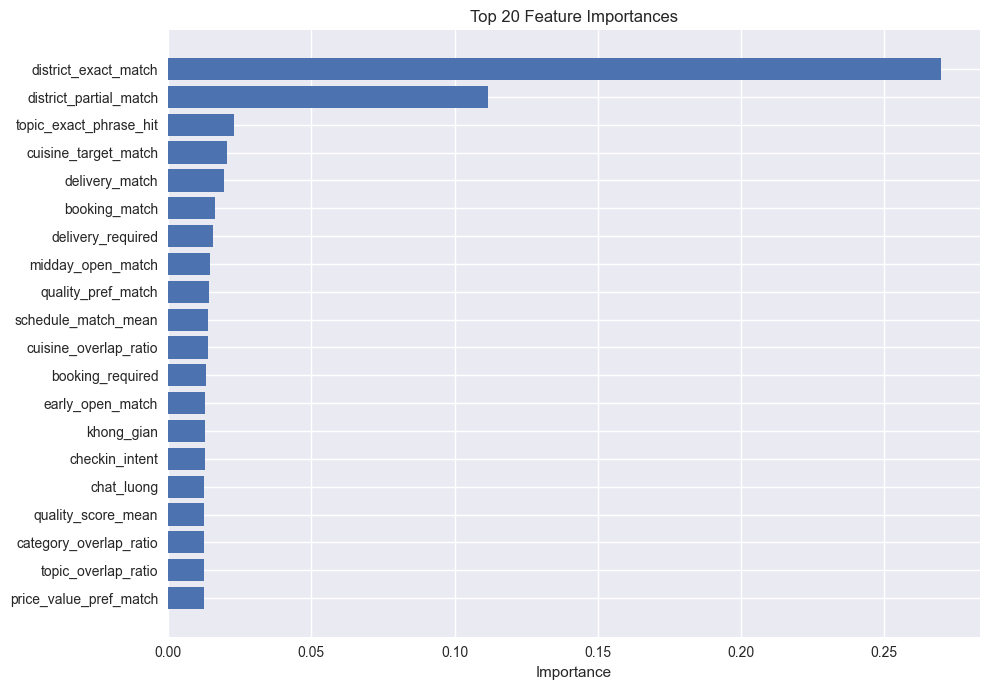

In [26]:

importance_df = feature_importance_frame(ranker, FEATURE_COLUMNS)
display(importance_df.head(20))

plt.figure(figsize=(10, 7))
top_importance = importance_df.head(20).iloc[::-1]
plt.barh(top_importance['feature'], top_importance['importance'])
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


In [27]:
sample_queries = eval_df["query"].drop_duplicates().head(4).tolist()

diagnostic_cols = [
    "query", "restaurant_name_meta", "district_meta", "cuisines_meta", "category_raw", "target_audience_raw",
    "rest_day_list", "active_days", "label", "pred_score", "district_exact_match", "cuisine_target_match",
    "category_target_match", "price_range_overlap", "delivery_match", "booking_match", "schedule_match_mean",
    "quality_pref_match", "service_pref_match", "space_pref_match", "position_pref_match", "popularity_blend",
]

for sample_query in sample_queries:
    print("\nQUERY:", sample_query)
    display(
        eval_df.loc[eval_df["query"] == sample_query, diagnostic_cols]
        .sort_values("pred_score", ascending=False)
        .head(5)
    )



QUERY: Cho mình hỏi quận 10 có buffet nào chất lượng tốt không


,query,restaurant_name_meta,district_meta,cuisines_meta,category_raw,target_audience_raw,rest_day_list,active_days,label,pred_score,district_exact_match,cuisine_target_match,category_target_match,price_range_overlap,delivery_match,booking_match,schedule_match_mean,quality_pref_match,service_pref_match,space_pref_match,position_pref_match,popularity_blend
0,Cho mình hỏi quận 10 có buffet nào chất lượng tốt không,007 - Lẩu & Coffee,Quận 10,Món Việt,Quán ăn,Gia đình || Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",1,0.308880,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2.151305
11,Cho mình hỏi quận 10 có buffet nào chất lượng tốt không,Hangout Restaurant,Quận 1,Món Việt,Buffet,Gia đình || Nhóm hội || Giới văn phòng || Khách du lịch,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",0,-0.591771,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
14,Cho mình hỏi quận 10 có buffet nào chất lượng tốt không,Buffet Corner - Estella Place,Quận 2,Món Việt,Buffet,Gia đình || Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",0,-0.852165,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000
7,Cho mình hỏi quận 10 có buffet nào chất lượng tốt không,One Plus - Buffet Trưa 99K++,Quận 1,Món Việt,Nhà hàng,Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",0,-1.102212,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,5.600460
4,Cho mình hỏi quận 10 có buffet nào chất lượng tốt không,Food Connexion Buffet - Pullman Hotel,Quận 1,,Sang trọng || Buffet || Nhà hàng,,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",0,-1.188090,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.103333,0.0,0.0,0.0,7.035862



QUERY: Cho mình hỏi quận 2 có quán món Âu nào vị trí đẹp không


,query,restaurant_name_meta,district_meta,cuisines_meta,category_raw,target_audience_raw,rest_day_list,active_days,label,pred_score,district_exact_match,cuisine_target_match,category_target_match,price_range_overlap,delivery_match,booking_match,schedule_match_mean,quality_pref_match,service_pref_match,space_pref_match,position_pref_match,popularity_blend
20,Cho mình hỏi quận 2 có quán món Âu nào vị trí đẹp không,Sozo - Cafe & Nhà Hàng Tây Âu,Quận 2,Món Âu,Nhà hàng,Gia đình || Nhóm hội || Giới văn phòng || Giới Manager,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",3,1.757509,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,3.931335
15,Cho mình hỏi quận 2 có quán món Âu nào vị trí đẹp không,TA Kitchen And Bar,Quận 2,Mỹ || Mexico || Món Thái || Pháp || Ý || Tây Ban Nha,Nhà hàng,Gia đình || Nhóm hội,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",4,1.698874,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,3.305147
18,Cho mình hỏi quận 2 có quán món Âu nào vị trí đẹp không,Quán 39 - Quán Nhậu,Quận 2,Món Việt,Quán nhậu,Gia đình || Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",1,1.484209,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,5.452414
26,Cho mình hỏi quận 2 có quán món Âu nào vị trí đẹp không,Chill Corner,Quận 2,Món Việt,Café/Dessert,Cặp đôi || Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",1,1.452752,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,5.309281
25,Cho mình hỏi quận 2 có quán món Âu nào vị trí đẹp không,Ẩm Thực Tây Ta,Quận 2,Món Việt,Quán ăn,Gia đình || Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",1,0.583221,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,3.550250



QUERY: Cho mình một quán món Việt ở quận 8 phục vụ ổn và được yêu thích


,query,restaurant_name_meta,district_meta,cuisines_meta,category_raw,target_audience_raw,rest_day_list,active_days,label,pred_score,district_exact_match,cuisine_target_match,category_target_match,price_range_overlap,delivery_match,booking_match,schedule_match_mean,quality_pref_match,service_pref_match,space_pref_match,position_pref_match,popularity_blend
43,Cho mình một quán món Việt ở quận 8 phục vụ ổn và được yêu thích,Công Viên Quán - Chuyên Các Món Rắn & Ốc,Quận 8,Món Việt,Quán ăn,Gia đình || Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",3,1.133165,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.292484
35,Cho mình một quán món Việt ở quận 8 phục vụ ổn và được yêu thích,Ba Thằng Xào - Quán Ăn Bình Dân,Quận Tân Phú,Món Việt,Quán ăn || Khu Ẩm Thực,Gia đình || Nhóm hội,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",1,-1.507876,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.420808
39,Cho mình một quán món Việt ở quận 8 phục vụ ổn và được yêu thích,Quán Ăn Như Ý,Quận 12,Món Việt,Quán ăn,Gia đình || Nhóm hội,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",1,-1.731527,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.518476
30,Cho mình một quán món Việt ở quận 8 phục vụ ổn và được yêu thích,Nhà Hàng Vị Ngon,Quận 2,Món Việt,Nhà hàng,Gia đình || Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",1,-1.750139,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.370817
41,Cho mình một quán món Việt ở quận 8 phục vụ ổn và được yêu thích,Quán Ốc Vip,Quận 11,Món Việt,Quán ăn,Sinh viên || Cặp đôi || Gia đình || Nhóm hội,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",1,-2.384592,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.732868



QUERY: Cho mình quán ăn ở Phú Nhuận phù hợp gặp bạn cũ vào tối cuối tuần, không quá ồn


,query,restaurant_name_meta,district_meta,cuisines_meta,category_raw,target_audience_raw,rest_day_list,active_days,label,pred_score,district_exact_match,cuisine_target_match,category_target_match,price_range_overlap,delivery_match,booking_match,schedule_match_mean,quality_pref_match,service_pref_match,space_pref_match,position_pref_match,popularity_blend
47,"Cho mình quán ăn ở Phú Nhuận phù hợp gặp bạn cũ vào tối cuối tuần, không quá ồn",Tình Bạn Quán - Quán Nhậu Vỉa Hè,Quận Phú Nhuận,Món Việt,Quán ăn || Quán nhậu,Sinh viên || Nhóm hội,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",4,1.307100,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,5.910265
46,"Cho mình quán ăn ở Phú Nhuận phù hợp gặp bạn cũ vào tối cuối tuần, không quá ồn",You Are Here - Thức Uống Take Away - Thích Quảng Đức,Quận Phú Nhuận,Món Việt,Ăn vặt/vỉa hè,Sinh viên || Cặp đôi || Gia đình || Nhóm hội,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",3,1.186000,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.430930
45,"Cho mình quán ăn ở Phú Nhuận phù hợp gặp bạn cũ vào tối cuối tuần, không quá ồn",Quán Nhậu Bình Dân 63,Quận Phú Nhuận,Món Việt,Quán ăn,Sinh viên || Gia đình || Nhóm hội,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",3,0.391570,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.191013
48,"Cho mình quán ăn ở Phú Nhuận phù hợp gặp bạn cũ vào tối cuối tuần, không quá ồn",Mình Ơi - Quán Ăn Bình Dân,Quận 11,Miền Tây,Quán ăn,Gia đình || Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",0,-2.515779,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.591267
56,"Cho mình quán ăn ở Phú Nhuận phù hợp gặp bạn cũ vào tối cuối tuần, không quá ồn",Quán Anh Em - Đặc Sản Cam Ranh,Quận 8,Món Miền Trung,Quán nhậu,Gia đình || Nhóm hội || Giới văn phòng,[],"[thu_hai, thu_ba, thu_tu, thu_nam, thu_sau, thu_bay, chu_nhat]",0,-2.579843,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.921772
